In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("visa_dataset.csv")
df.head()

,application_id,country_of_application,destination_country,visa_type,applicant_age,education_level,annual_income,bank_balance,travel_history_count,previous_visa_rejections,employment_status,sponsor_available,documents_complete,interview_score,application_month,visa_status,processing_time_days
0,V001,India,USA,Student,22,Bachelors,15000,8000,1,0,Student,1,1,8,1,Approved,28
1,V002,India,Canada,Work,29,Masters,25000,12000,3,1,Employed,0,1,6,2,Approved,35
2,V003,Nigeria,UK,Tourist,35,Bachelors,9000,3000,0,2,Self-employed,0,0,4,3,Rejected,45
3,V004,India,Australia,Student,24,Masters,18000,9000,2,0,Student,1,1,9,4,Approved,30
4,V005,Pakistan,USA,Work,31,Bachelors,20000,7000,1,1,Employed,0,1,5,5,Rejected,40


In [3]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   application_id            20 non-null     object
 1   country_of_application    20 non-null     object
 2   destination_country       20 non-null     object
 3   visa_type                 20 non-null     object
 4   applicant_age             20 non-null     int64 
 5   education_level           20 non-null     object
 6   annual_income             20 non-null     int64 
 7   bank_balance              20 non-null     int64 
 8   travel_history_count      20 non-null     int64 
 9   previous_visa_rejections  20 non-null     int64 
 10  employment_status         20 non-null     object
 11  sponsor_available         20 non-null     int64 
 12  documents_complete        20 non-null     int64 
 13  interview_score           20 non-null     int64 
 14  application_month         20

In [6]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [7]:
for column in df.select_dtypes(include=['object']).columns:
    df[column] = label_encoder.fit_transform(df[column])

In [8]:
df.head()

,application_id,country_of_application,destination_country,visa_type,applicant_age,education_level,annual_income,bank_balance,travel_history_count,previous_visa_rejections,employment_status,sponsor_available,documents_complete,interview_score,application_month,visa_status,processing_time_days
0,0,2,3,0,22,0,15000,8000,1,0,2,1,1,8,1,0,28
1,1,2,1,2,29,2,25000,12000,3,1,0,0,1,6,2,0,35
2,2,4,2,1,35,0,9000,3000,0,2,1,0,0,4,3,1,45
3,3,2,0,0,24,2,18000,9000,2,0,2,1,1,9,4,0,30
4,4,5,3,2,31,0,20000,7000,1,1,0,0,1,5,5,1,40


In [11]:
X = df.drop("visa_status", axis=1)
y = df["visa_status"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [16]:
X2 = df.drop("processing_time_days", axis=1)
y2 = df["processing_time_days"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X2_train, y2_train)

print("processing time Prediction Score:", reg_model.score(X2_test, y2_test))

processing time Prediction Score: -12.463613618925775


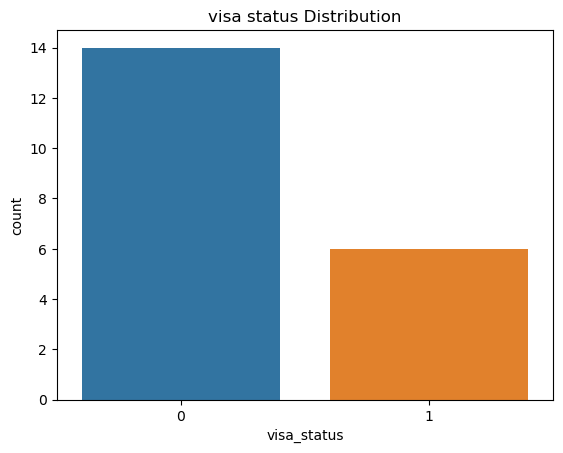

In [17]:
sns.countplot(x="visa_status", data=df)
plt.title("visa status Distribution")
plt.show()

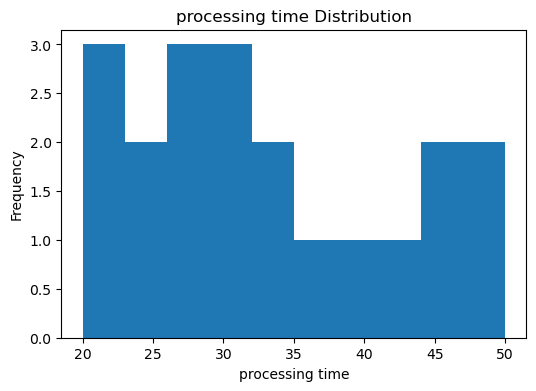

In [19]:
plt.figure(figsize=(6,4))
plt.hist(df["processing_time_days"], bins=10)
plt.title("processing time Distribution")
plt.xlabel("processing time")
plt.ylabel("Frequency")
plt.show()

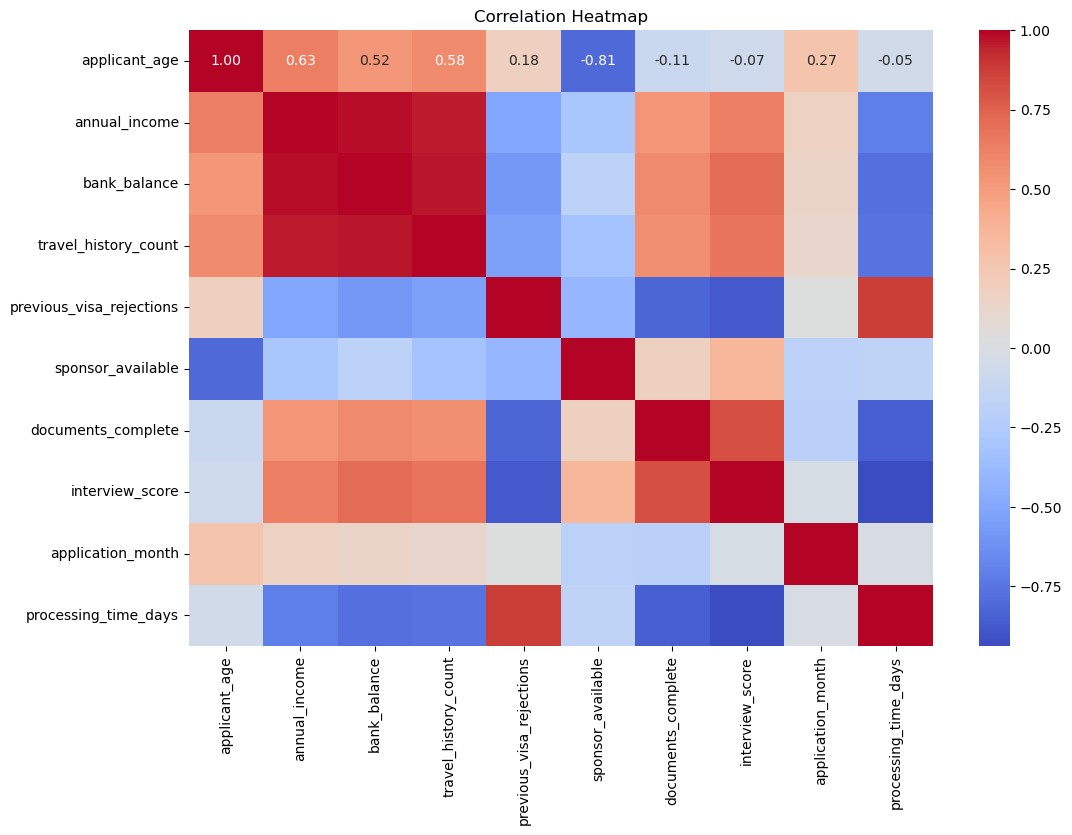

In [22]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

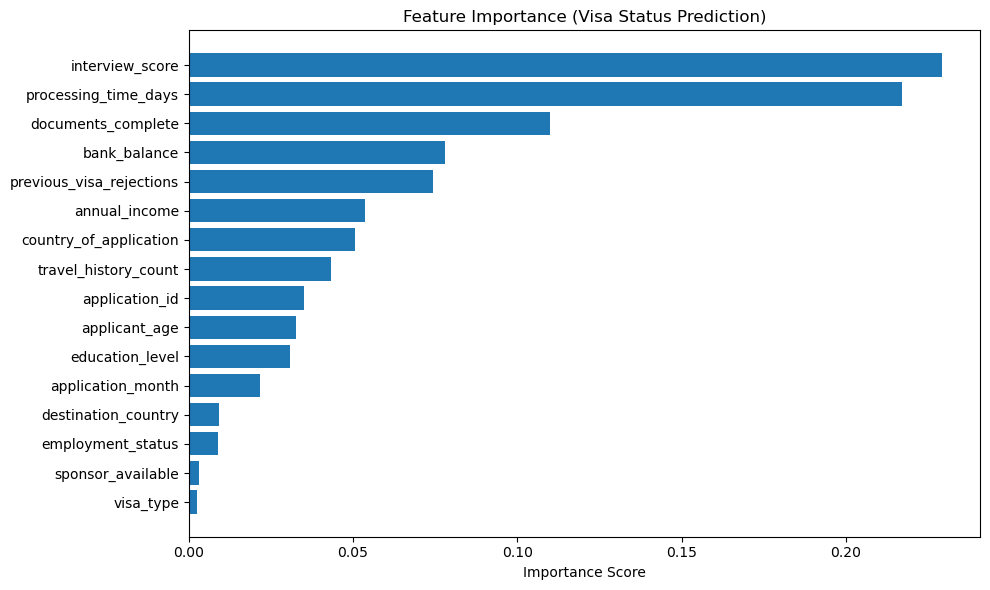

In [24]:
plt.figure(figsize=(10,6))
sorted_idx = importances.argsort()

plt.barh(range(len(sorted_idx)), importances[sorted_idx])
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
plt.xlabel("Importance Score")
plt.title("Feature Importance (Visa Status Prediction)")
plt.tight_layout()
plt.show()